<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_1_Introduction_and_Data_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction and Data Set Up
---

**To follow along, please make your own copy of this notebook by selecting `File -> Save a copy in Drive` from the Menu bar above.**

Link to this notebook:




## Dataset Overview

In this project, we will use the Uber Ride Analytics dataset sourced from [Kaggle](https://www.kaggle.com/), a public platform that hosts real-world datasets commonly used for learning, research, and portfolio projects.

📍 **Dataset source:**

[Uber Ride Analytics Data (Kaggle)](https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard)


**What this dataset contains**

This dataset includes detailed ride-sharing data from Uber operations in 2024, offering a realistic view of how a large mobility platform operates. It captures information related to ride bookings, cancellations, fares, vehicle types, and customer behavior—similar to the data analysts and data scientists work with in industry.


**Why we’re using this dataset**

This dataset allows us to explore real product and operational questions, such as:

- When and why rides get canceled

- How ride demand and fares change over time

- What metrics can be used to understand growth, retention, and performance

📂 Note: A local copy of the dataset is provided in the same folder as this notebook so you can load it directly and start analyzing without additional setup.

## Uploading Data into Google Colab

There are two ways to upload your dataset into a Colab notebook. Both work, but one is strongly recommended.


#### Option 1: Upload to Google Drive (Recommended)

This method allows your data to persist across sessions, so you won’t need to re-upload files every time you reopen or rerun the notebook.

**Step 1: Upload the file to Google Drive**

Upload the dataset (CSV file) to a folder in your Google Drive (for example: MyDrive/build-project/).

**Step 2: Mount Google Drive in Colab**

Run the following code:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Follow the prompt to authorize access.

**Step 3: Load the dataset**

Update the file path to match where you uploaded the file in Drive:

In [5]:
import pandas as pd

# Update the file path below to match where your dataset is stored
# Example: '/content/drive/MyDrive/build-project/uber_rides_data.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data.csv'

# Use pandas to read the CSV file into a DataFrame
# This creates a table-like structure that we can analyze using Python
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
# This helps verify that the data was loaded correctly
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


#### Option 2: Upload Directly to Colab (Temporary Storage)

This method is faster for quick testing but requires re-uploading the file whenever the runtime resets.

**Step 1: Upload the file**

Run the following code and select your dataset file:

In [1]:
from google.colab import files
uploaded = files.upload()

**Step 2: Load the dataset**

Once uploaded, load it directly:

In [6]:
import pandas as pd

# Use pandas to read the CSV file into a DataFrame
# This creates a table-like structure that we can analyze using Python
df = pd.read_csv('uber_rides_data.csv')

# Display the first few rows of the dataset
# This helps verify that the data was loaded correctly
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'uber_rides_data.csv'

⚠️ Important: Files uploaded this way are stored temporarily and will be deleted when the runtime resets.





**Recommendation**:
---
If you plan to work on this notebook over multiple sessions (which you will throughout this project), use Option 1 (Google Drive) to avoid repeatedly uploading files.


## Let's take a Closer Look at the Data

Before jumping into analysis, it’s important to understand what data we have and what each column represents. A good first step is to inspect the dataset’s structure, data types, and any missing values.

Run the following command to get a high-level overview of the dataset:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

This will show you:

- The number of rows and columns

- Column names

- Data types (e.g., numeric, text, dates)

- Whether any columns have missing values

Understanding this information helps you decide what cleaning and transformations are needed in later steps.

### Data Schema

| Column Name                           | Description                                                                         |
| ------------------------------------- | ----------------------------------------------------------------------------------- |
| **Date**                              | Date of the booking                                                                 |
| **Time**                              | Time of the booking                                                                 |
| **Booking ID**                        | Unique identifier for each ride booking                                             |
| **Booking Status**                    | Status of the booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.) |
| **Customer ID**                       | Unique identifier for customers                                                     |
| **Vehicle Type**                      | Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)        |
| **Pickup Location**                   | Starting location of the ride                                                       |
| **Drop Location**                     | Destination location of the ride                                                    |
| **Avg VTAT**                          | Average time for driver to reach pickup location (in minutes)                       |
| **Avg CTAT**                          | Average trip duration from pickup to destination (in minutes)                       |
| **Cancelled Rides by Customer**       | Flag indicating customer-initiated cancellation                                     |
| **Reason for cancelling by Customer** | Reason provided for customer cancellation                                           |
| **Cancelled Rides by Driver**         | Flag indicating driver-initiated cancellation                                       |
| **Driver Cancellation Reason**        | Reason provided for driver cancellation                                             |
| **Incomplete Rides**                  | Flag indicating incomplete rides                                                    |
| **Incomplete Rides Reason**           | Reason for incomplete rides                                                         |
| **Booking Value**                     | Total fare amount for the ride                                                      |
| **Ride Distance**                     | Distance covered during the ride (in kilometers)                                    |
| **Driver Ratings**                    | Rating given to the driver (1–5 scale)                                              |
| **Customer Rating**                   | Rating given by the customer (1–5 scale)                                            |
| **Payment Method**                    | Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)           |


As you review this schema and the output of `df.info()`, start thinking about:

- Which columns may need cleaning or type conversion

- Which fields are useful for understanding ride demand, cancellations, and revenue

In [10]:
# clean ID columns (remove triple quotes)
df['Booking ID'] = df['Booking ID'].str.replace('"', '', regex=False)
df['Customer ID'] = df['Customer ID'].str.replace('"', '', regex=False)

In [12]:
# standarize vehicle types
df['Vehicle Type'] = df['Vehicle Type'].str.strip().str.title()

In [14]:
# create a unified timestamp and extract features
df['Pickup_Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Hour'] = df['Pickup_Timestamp'].dt.hour
df['Day_of_Week'] = df['Pickup_Timestamp'].dt.day_name()

In [15]:
# define peak hours
def get_time_period(hour):
    if 7 <= hour <= 10: return 'Morning Peak'
    elif 17 <= hour <= 21: return 'Evening Peak'
    else: return 'Off-Peak'

df['Time_Period'] = df['Hour'].apply(get_time_period)

In [16]:
# segmented Null analysis
null_stats = df.groupby('Vehicle Type')[['Avg VTAT', 'Avg CTAT', 'Booking Value']].apply(lambda x: x.isnull().mean() * 100)
print('Null Data % by Vehicle Type:\n', null_stats)

Null Data % by Vehicle Type:
                Avg VTAT   Avg CTAT  Booking Value
Vehicle Type                                     
Auto           7.164809  32.079959      32.079959
Bike           6.674957  31.775991      31.775991
Ebike          7.066401  31.978782      31.978782
Go Mini        6.760384  31.678186      31.678186
Go Sedan       7.221547  32.508014      32.508014
Premier Sedan  7.067528  32.002650      32.002650
Uber Xl        7.080243  31.557653      31.557653


In [17]:
# save cleaned version for week 2
df.to_csv('cleaned_uber_data_week1.csv', index=False)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# calculate 'No Driver Found' rate per hour
# use .mean() on boolean to get percentage
df['Is_No_Driver_Found'] = df['Booking Status'] == 'No Driver Found'
hourly_ndf_rate = df.groupby('Hour')['Is_No_Driver_Found'].mean() * 100

<Axes: xlabel='Hour'>

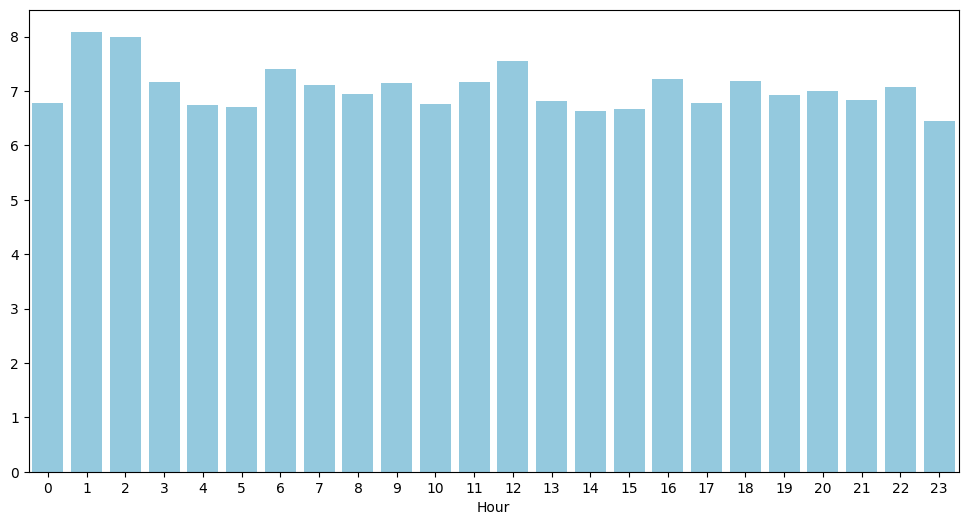

In [21]:
# create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_ndf_rate.index, y=hourly_ndf_rate.values, color='skyblue')

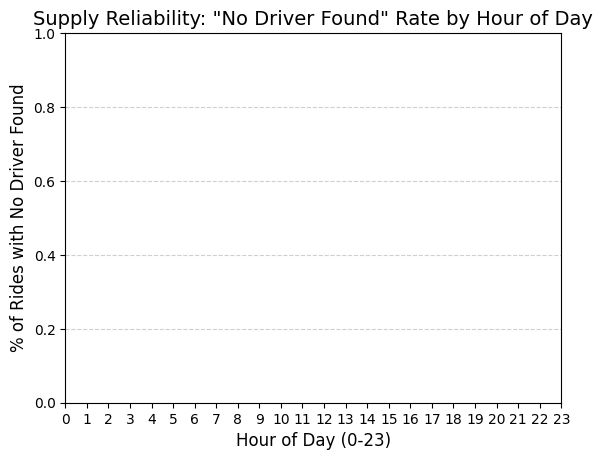

In [23]:
# add labels and titles
plt.title('Supply Reliability: "No Driver Found" Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('% of Rides with No Driver Found', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [24]:
# print the Peak Shortage Hour
peak_hour = hourly_ndf_rate.idxmax()
peak_value = hourly_ndf_rate.max()
print(f'Insight: The highest supply shortage occurs at {peak_hour}:00 with a {peak_value: .2f}% failure rate.')

Insight: The highest supply shortage occurs at 1:00 with a  8.09% failure rate.
